## Load Training and Validation Dataset

This cell loads the image dataset from folders using TensorFlow.

- Images are automatically labeled based on folder names
- The dataset is split into training and validation data
- `class_names` stores the list of all disease classes

These class names are later used for prediction and evaluation.


In [ ]:
import tensorflow as tf

dataset_dir = "PlantVillage"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical",   
    validation_split=0.2,
    subset="training",
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical",
    validation_split=0.2,
    subset="validation",
    seed=42
)

class_names = train_ds.class_names
print(class_names)


c:\Users\Venkatesh R\Documents\Crop_Disease_Classification\env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


## Visualize Sample Images

This cell displays some sample images from the training dataset.

It helps to:
- Verify images are loaded correctly
- Check image quality
- Confirm labels match the images


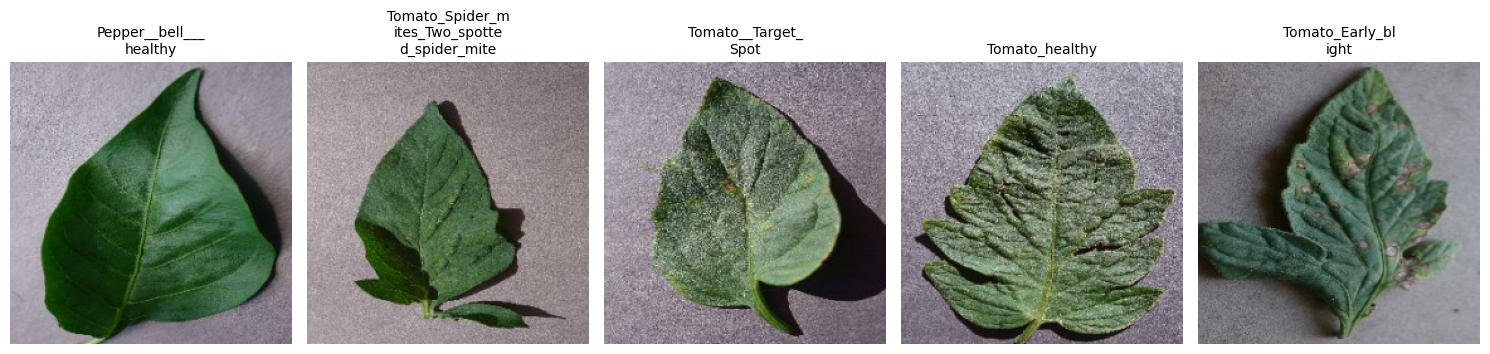

In [2]:
import matplotlib.pyplot as plt
import textwrap

plt.figure(figsize=(15,5))  

for images, labels in train_ds.take(1):
    for i in range(5):
        ax = plt.subplot(1,5,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        title = "\n".join(textwrap.wrap(class_names[labels[i].numpy().argmax()], 15))
        plt.title(title, fontsize=10)
        plt.axis("off")

plt.tight_layout()
plt.show()


## Check Class Distribution

This cell counts how many images are present in each class.

A bar chart is shown to understand:
- Class imbalance
- Which classes have more or fewer images

This is important for model performance.


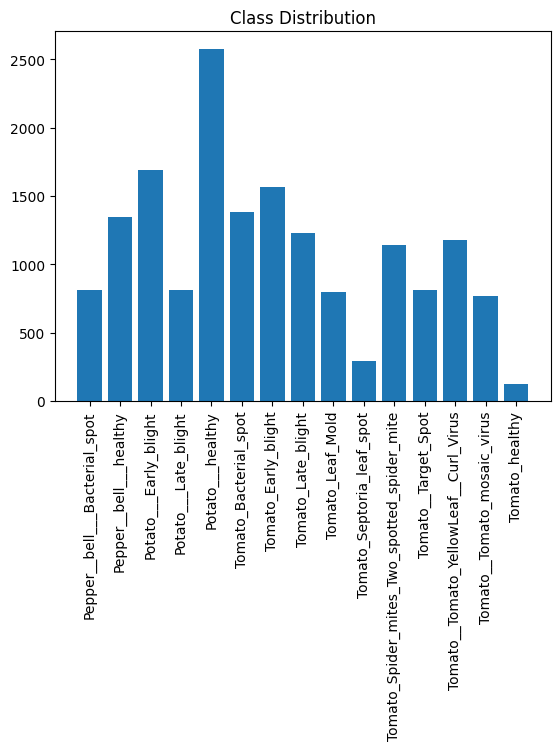

In [3]:
import numpy as np
from collections import Counter

counts = Counter()

for _, labels in train_ds:
    counts.update(labels.numpy().argmax(axis=1))

plt.bar(range(len(class_names)), counts.values())
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.title("Class Distribution")
plt.show()


In [4]:
for images, _ in train_ds.take(1):
    print(images.shape)  

(32, 224, 224, 3)


## Check Class Distribution

This cell counts how many images are present in each class.

A bar chart is shown to understand:
- Class imbalance
- Which classes have more or fewer images

This is important for model performance.


In [8]:
def get_image_distribution(dataset=train_ds):
    healthy_class = [i for i, name in enumerate(class_names) if "healthy" in name.lower()]
    healthy_count = 0
    diseased_count = 0

    for _, labels in dataset:
        labels_idx = labels.numpy().argmax(axis=1)
        healthy_count += sum([1 for l in labels_idx if l in healthy_class])
        diseased_count += sum([1 for l in labels_idx if l not in healthy_class])

    print("Healthy:", healthy_count, "Diseased:", diseased_count)



In [9]:
get_image_distribution(train_ds)

Healthy: 2526 Diseased: 13985


## Data Augmentation

This cell defines data augmentation techniques.

Augmentation helps the model learn better by:
- Rotating images
- Flipping images
- Zooming images

This reduces overfitting.


In [10]:
from tensorflow.keras import layers

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

train_ds_unbatched = train_ds.unbatch()

healthy_idx = tf.constant(
    [i for i, name in enumerate(class_names) if "healthy" in name.lower()],
    dtype=tf.int64
)

def is_healthy(image, label):
    return tf.reduce_any(tf.equal(tf.argmax(label), healthy_idx))

healthy_ds = train_ds_unbatched.filter(is_healthy)
diseased_ds = train_ds_unbatched.filter(lambda x, y: tf.logical_not(is_healthy(x, y)))

def augment_image(image, label):
    return augment(image), label

augmented_healthy_ds = healthy_ds.map(augment_image)

# repeat to increase count
augmented_healthy_ds = augmented_healthy_ds.repeat(4)

train_ds_balanced = diseased_ds.concatenate(healthy_ds)
train_ds_balanced = train_ds_balanced.concatenate(augmented_healthy_ds)

train_ds_balanced = train_ds_balanced.shuffle(20000, seed=42)
train_ds_balanced = train_ds_balanced.batch(32)


In [12]:
total_rows = 0
for images, labels in train_ds_balanced:
    total_rows += images.shape[0]

print("Total samples:", total_rows)


Total samples: 26615


In [13]:
get_image_distribution(train_ds_balanced)


Healthy: 12630 Diseased: 13985


## Model training

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

AUTOTUNE = tf.data.AUTOTUNE

train_ds_balanced = train_ds_balanced.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


## Load Pretrained Base Model

This cell loads a pretrained CNN model (MobileNetV2).

- Pretrained on ImageNet
- Used as a feature extractor
- Speeds up training and improves accuracy


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Build Classification Model

This cell creates the full model.

Model structure:
- Rescaling layer (normalizes images)
- Pretrained base model
- Global Average Pooling
- Dense layer
- Dropout for regularization
- Softmax output layer


In [16]:
model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])


## Compile Model

This cell compiles the model with:

- Optimizer: Adam
- Loss function: Categorical Crossentropy
- Metric: Accuracy

This prepares the model for training.


In [17]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


## Train the Model

This cell trains the model using:

- Training dataset
- Validation dataset
- Multiple epochs

Training history is stored for analysis.


In [19]:
history = model.fit(
    train_ds_balanced,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
    832/Unknown 930s 972ms/step - accuracy: 0.9047 - loss: 0.2821

c:\Users\Venkatesh R\Documents\Crop_Disease_Classification\env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


832/832 ━━━━━━━━━━━━━━━━━━━━ 1044s 1s/step - accuracy: 0.9132 - loss: 0.2578 - val_accuracy: 0.9009 - val_loss: 0.2890
Epoch 2/5
832/832 ━━━━━━━━━━━━━━━━━━━━ 1063s 1s/step - accuracy: 0.9291 - loss: 0.2082 - val_accuracy: 0.9009 - val_loss: 0.2749
Epoch 3/5
832/832 ━━━━━━━━━━━━━━━━━━━━ 1310s 1s/step - accuracy: 0.9394 - loss: 0.1765 - val_accuracy: 0.9026 - val_loss: 0.2763
Epoch 4/5
832/832 ━━━━━━━━━━━━━━━━━━━━ 2854s 3s/step - accuracy: 0.9474 - loss: 0.1519 - val_accuracy: 0.9079 - val_loss: 0.2561
Epoch 5/5
832/832 ━━━━━━━━━━━━━━━━━━━━ 1628s 2s/step - accuracy: 0.9529 - loss: 0.1386 - val_accuracy: 0.9162 - val_loss: 0.2383


In [21]:
model.save("plant_disease_classifier_model.h5")

## Confusion Matrix

This cell creates a confusion matrix.

It shows:
- Correct predictions
- Which classes are confused with others

Very useful for debugging misclassifications.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 981ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 970ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 978ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 953ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

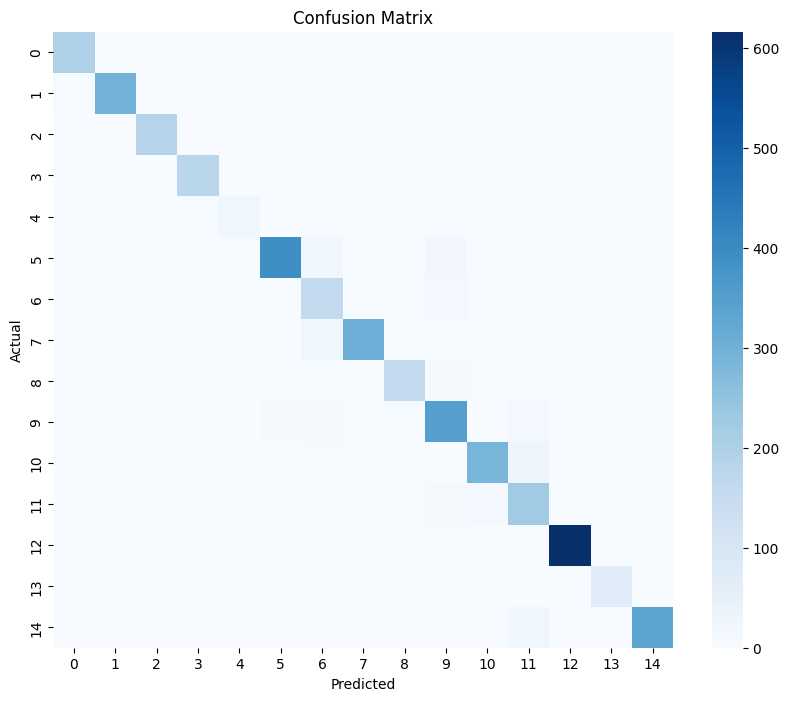

In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Collect Correct and Incorrect Predictions

This cell separates:
- Correct predictions
- Incorrect predictions

It helps in visual analysis of model behavior.


In [25]:
correct = []
incorrect = []

for images, labels in val_ds:
    preds = model.predict(images)
    for i in range(len(images)):
        true = np.argmax(labels[i])
        pred = np.argmax(preds[i])

        if true == pred and len(correct) < 5:
            correct.append((images[i], true, pred))
        elif true != pred and len(incorrect) < 5:
            incorrect.append((images[i], true, pred))

        if len(correct) == 5 and len(incorrect) == 5:
            break
    if len(correct) == 5 and len(incorrect) == 5:
        break


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


## Show Prediction Examples

This cell displays sample images that were:
- Predicted correctly
- Predicted incorrectly

This helps visually understand model mistakes.


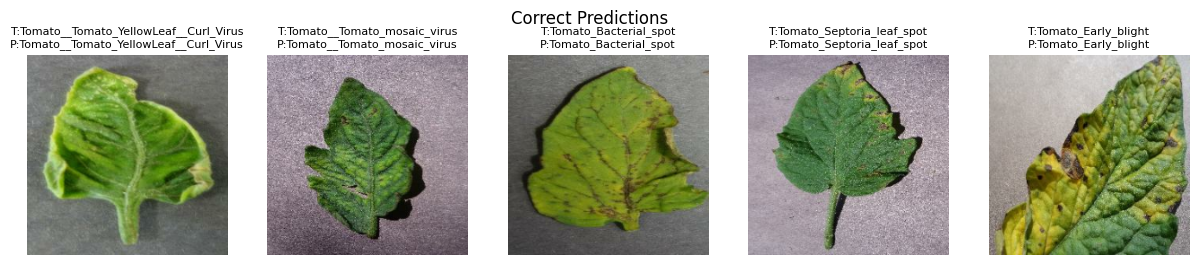

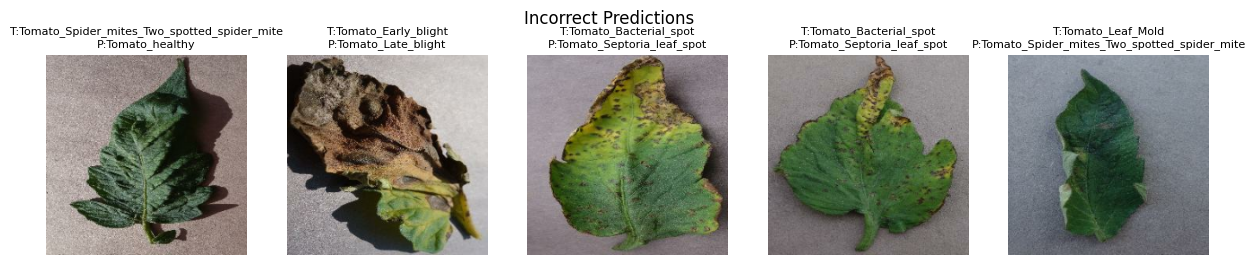

In [26]:
def show_images(samples, title):
    plt.figure(figsize=(15,3))
    for i, (img, t, p) in enumerate(samples):
        ax = plt.subplot(1,5,i+1)
        plt.imshow(img.numpy().astype("uint8"))
        plt.title(f"T:{class_names[t]}\nP:{class_names[p]}", fontsize=8)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_images(correct, "Correct Predictions")
show_images(incorrect, "Incorrect Predictions")


## Classification Report

This cell prints:
- Precision
- Recall
- F1-score
- Support for each class

It gives detailed insight into model performance.


In [ ]:
from sklearn.metrics import classification_report


y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())


print(classification_report(y_true, y_pred, target_names=class_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 973ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 948ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 965ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 971ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 974ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 961ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 937ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 913ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 932ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 911ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 926ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 916ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step
1/1 